In [1]:
import pandas as pd
import ast
import numpy as np
import os
from sklearn.cluster import KMeans
from tqdm import tqdm

In [2]:
data_folder = f'.'
svd_embeddings = pd.read_csv(f'{data_folder}/svd_embeddings.csv', low_memory=False)

In [3]:
anonymized = svd_embeddings.song_id.unique()
anonymized_to_integers = {anonymized_id: integer for integer, anonymized_id in enumerate(anonymized)}

In [4]:
# svd_embeddings = svd_embeddings.drop(columns=["Unnamed: 0"])
svd_embeddings.song_id = svd_embeddings.song_id.map(anonymized_to_integers)

In [5]:
distances_index_song_id = svd_embeddings.rename_axis('distances_index').reset_index()[['distances_index', 'song_id']]

In [6]:
# SVD embeddings are 128-dimensional
len(svd_embeddings.list_embeddings.values[0].split(', '))

128

In [7]:
svd_embeddings['list_embeddings'] = svd_embeddings['list_embeddings'].apply(ast.literal_eval)

In [8]:
svd_embeddings = svd_embeddings.set_index('song_id')

In [9]:
%%time 
svd_embeddings_series = svd_embeddings.list_embeddings.apply(pd.Series)

CPU times: user 3.27 s, sys: 132 ms, total: 3.4 s
Wall time: 3.33 s


In [10]:
svd_embeddings_matrix = svd_embeddings_series.values.astype(np.float32)

In [11]:
svd_embeddings_matrix_path = os.path.join(data_folder, 'svd_embeddings_matrix_2024_11_04.npy')
# np.save(svd_embeddings_matrix_path, svd_embeddings_matrix)
# svd_embeddings_matrix = np.load(svd_embeddings_matrix_path)

In [12]:
inertia = []
n_clusters_list = range(2, 128)
for n_clusters in tqdm(n_clusters_list):
    clusterer = KMeans(n_clusters=n_clusters, random_state=10).fit(svd_embeddings_matrix)
    inertia.append(clusterer.inertia_ / n_clusters)

100%|██████████| 126/126 [02:10<00:00,  1.03s/it]


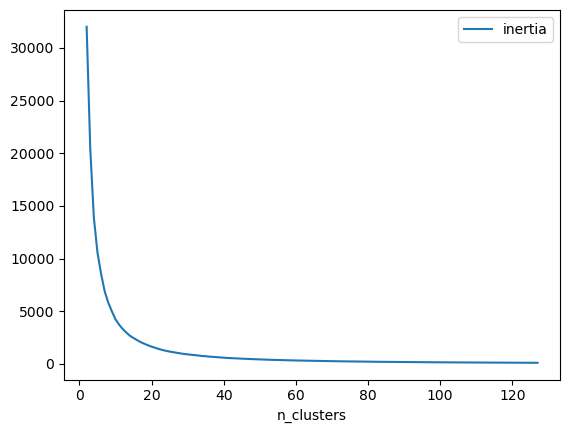

In [13]:
inertias = pd.DataFrame({'n_clusters': n_clusters_list, 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
